# Springboard Regression Case Study - The Red Wine Dataset - Tier 3

Welcome to the Springboard Regression case study! Please note: this is ***Tier 3*** of the case study.

This case study was designed for you to **use Python to apply the knowledge you've acquired in reading *The Art of Statistics* (hereinafter *AoS*) by Professor Spiegelhalter**. Specifically, the case study will get you doing regression analysis; a method discussed in Chapter 5 on p.121. It might be useful to have the book open at that page when doing the case study to remind you of what it is we're up to (but bear in mind that other statistical concepts, such as training and testing, will be applied, so you might have to glance at other chapters too).  

The aim is to ***use exploratory data analysis (EDA) and regression to predict alcohol levels in wine with a model that's as accurate as possible***. 

We'll try a *univariate* analysis (one involving a single explanatory variable) as well as a *multivariate* one (involving multiple explanatory variables), and we'll iterate together towards a decent model by the end of the notebook. The main thing is for you to see how regression analysis looks in Python and jupyter, and to get some practice implementing this analysis.

Throughout this case study, **questions** will be asked in the markdown cells. Try to **answer these yourself in a simple text file** when they come up. Most of the time, the answers will become clear as you progress through the notebook. Some of the answers may require a little research with Google and other basic resources available to every data scientist. 

For this notebook, we're going to use the red wine dataset, wineQualityReds.csv. Make sure it's downloaded and sitting in your working directory. This is a very common dataset for practicing regression analysis and is actually freely available on Kaggle, [here](https://www.kaggle.com/piyushgoyal443/red-wine-dataset).

You're pretty familiar with the data science pipeline at this point. This project will have the following structure: 
**1. Sourcing and loading** 
- Import relevant libraries
- Load the data 
- Exploring the data
- Choosing a dependent variable
 
**2. Cleaning, transforming, and visualizing**
- Visualizing correlations
  
  
**3. Modeling** 
- Train/Test split
- Making a Linear regression model: your first model
- Making a Linear regression model: your second model: Ordinary Least Squares (OLS) 
- Making a Linear regression model: your third model: multiple linear regression
- Making a Linear regression model: your fourth model: avoiding redundancy

**4. Evaluating and concluding** 
- Reflection 
- Which model was best?
- Other regression algorithms

### 1. Sourcing and loading

#### 1a. Import relevant libraries 

In [1]:
# Import NumPy for numerical calculations and array operations.
import numpy as np

# Import pandas for loading, cleaning, and analyzing tabular data.
import pandas as pd

# Import Matplotlib's pyplot module for creating visualizations.
import matplotlib.pyplot as plt

# Import Seaborn for statistical data visualization.
import seaborn as sns

# Import Statsmodels for statistical modeling, including Ordinary Least Squares (OLS).
import statsmodels.api as sm

# Import abline_plot for adding a straight reference/regression line to a plot.
from statsmodels.graphics.api import abline_plot

# Import regression evaluation metrics:
# mean_squared_error calculates the average squared prediction error.
# r2_score calculates the coefficient of determination (R-squared).
from sklearn.metrics import mean_squared_error, r2_score

# Import train_test_split to divide the data into training and testing datasets.
from sklearn.model_selection import train_test_split

# Import sklearn's linear_model module for LinearRegression
# and preprocessing for data preprocessing tasks.
from sklearn import linear_model, preprocessing

# Import warnings so that unnecessary warning messages can be suppressed.
import warnings

# Don't worry about the following two instructions: they just suppress warnings that could occur later.
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.filterwarnings(action="ignore", module="scipy", message="^internal gelsd")

#### 1b. Load the data

In [2]:
# Load the data. 
wine = pd.read_csv("wineQualityReds.csv")

# Display the first five rows to check that the data loaded correctly.
wine.head()

,Unnamed: 0,fixed.acidity,volatile.acidity,citric.acid,residual.sugar,chlorides,free.sulfur.dioxide,total.sulfur.dioxide,density,pH,sulphates,alcohol,quality
0,1,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,2,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,3,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,4,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,5,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


#### 1c. Exploring the data

In [3]:
# Check the first five rows to see the appearance and structure of the dataset.
wine.head()

,Unnamed: 0,fixed.acidity,volatile.acidity,citric.acid,residual.sugar,chlorides,free.sulfur.dioxide,total.sulfur.dioxide,density,pH,sulphates,alcohol,quality
0,1,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,2,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,3,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,4,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,5,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
# Another very useful method to call on a recently imported dataset is .info(). Call it here to get a good
# overview of the data
wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            1599 non-null   int64  
 1   fixed.acidity         1599 non-null   float64
 2   volatile.acidity      1599 non-null   float64
 3   citric.acid           1599 non-null   float64
 4   residual.sugar        1599 non-null   float64
 5   chlorides             1599 non-null   float64
 6   free.sulfur.dioxide   1599 non-null   float64
 7   total.sulfur.dioxide  1599 non-null   float64
 8   density               1599 non-null   float64
 9   pH                    1599 non-null   float64
 10  sulphates             1599 non-null   float64
 11  alcohol               1599 non-null   float64
 12  quality               1599 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 162.5 KB


What can you infer about the nature of these variables, as output by the info() method?
- The dataset contains both continuous and discrete variables. Most of the chemical measurements, such as fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, density, pH, sulphates, and alcohol, are continuous numerical variables. The quality variable is an integer (int64) and represents discrete quality categories. There are no missing values in the dataset, based on the non-null counts shown by info().



Which variables might be suitable for regression analysis, and why? For those variables that aren't suitable for regression analysis, is there another type of statistical modeling for which they are suitable?
- The continuous numerical variables are suitable for regression because regression is generally used to predict a continuous outcome. The quality variable is not ideal for ordinary linear regression because it contains discrete integer categories. Instead, quality could be used as the target variable in a classification problem, because the goal would be to predict a category.

In [5]:
# Check the dimensions of the dataset.
# The result shows the number of rows and columns.
wine.shape

(1599, 13)

#### 1d. Choosing a dependent variable

We now need to pick a dependent variable for our regression analysis: a variable whose values we will predict. 

'Quality' seems to be as good a candidate as any. Let's check it out. One of the quickest and most informative ways to understand a variable is to make a histogram of it. This gives us an idea of both the center and spread of its values. 

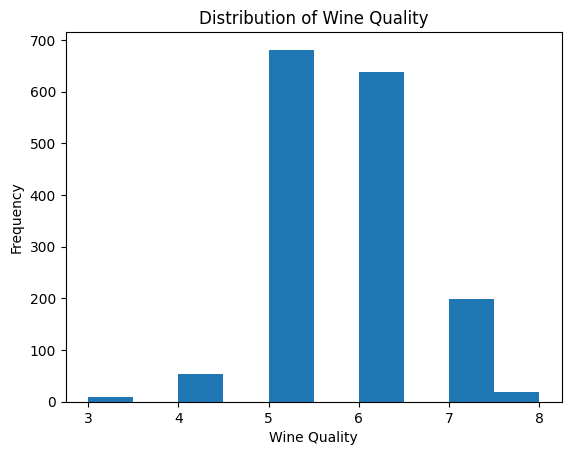

In [6]:
# Create a histogram showing the distribution of wine quality scores.
plt.hist(wine["quality"])

# Label the x-axis.
plt.xlabel("Wine Quality")

# Label the y-axis.
plt.ylabel("Frequency")

# Add a title to the histogram.
plt.title("Distribution of Wine Quality")

# Display the plot.
plt.show()

We can see so much about the quality variable just from this simple visualization. Answer yourself: what value do most wines have for quality? What is the minimum quality value below, and the maximum quality value? What is the range? Remind yourself of these summary statistical concepts by looking at p.49 of the *AoS*.

But can you think of a problem with making this variable the dependent variable of regression analysis? Remember the example in *AoS* on p.122 of predicting the heights of children from the heights of parents? Take a moment here to think about potential problems before reading on. 

The issue is this: quality is a *discrete* variable, in that its values are integers (whole numbers) rather than floating point numbers. Thus, quality is not a *continuous* variable. But this means that it's actually not the best target for regression analysis. 

Before we dismiss the quality variable, however, let's verify that it is indeed a discrete variable with some further exploration. 

In [7]:
# Get a basic statistical summary of the variable 
wine["quality"].describe()

# What do you notice from this summary?
# This summary includes count, mean, standard deviation, minimum,
# quartiles, and maximum.

count    1599.000000
mean        5.636023
std         0.807569
min         3.000000
25%         5.000000
50%         6.000000
75%         6.000000
max         8.000000
Name: quality, dtype: float64

In [8]:
# Get a list of the values of the quality variable, and the number of occurrences of each.
# sort_index() displays the quality values in numerical order.
wine["quality"].value_counts().sort_index()

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

The outputs of the describe() and value_counts() methods are consistent with our histogram, and since there are just as many values as there are rows in the dataset, we can infer that there are no NAs for the quality variable. 

But scroll up again to when we called info() on our wine dataset. We could have seen there, already, that the quality variable had int64 as its type. As a result, we had sufficient information, already, to know that the quality variable was not appropriate for regression analysis. Did you figure this out yourself? If so, kudos to you!

The quality variable would, however, conduce to proper classification analysis. This is because, while the values for the quality variable are numeric, those numeric discrete values represent *categories*; and the prediction of category-placement is most often best done by classification algorithms. You saw the decision tree output by running a classification algorithm on the Titanic dataset on p.168 of Chapter 6 of *AoS*. For now, we'll continue with our regression analysis, and continue our search for a suitable dependent variable. 

Now, since the rest of the variables of our wine dataset are continuous, we could — in theory — pick any of them. But that does not mean that are all equally sutiable choices. What counts as a suitable dependent variable for regression analysis is determined not just by *intrinsic* features of the dataset (such as data types, number of NAs etc) but by *extrinsic* features, such as, simply, which variables are the most interesting or useful to predict, given our aims and values in the context we're in. Almost always, we can only determine which variables are sensible choices for dependent variables with some **domain knowledge**. 

Not all of you might be wine buffs, but one very important and interesting quality in wine is [acidity](https://waterhouse.ucdavis.edu/whats-in-wine/fixed-acidity). As the Waterhouse Lab at the University of California explains, 'acids impart the sourness or tartness that is a fundamental feature in wine taste.  Wines lacking in acid are "flat." Chemically the acids influence titrable acidity which affects taste and pH which affects  color, stability to oxidation, and consequantly the overall lifespan of a wine.'

If we cannot predict quality, then it seems like **fixed acidity** might be a great option for a dependent variable. Let's go for that.

So if we're going for fixed acidity as our dependent variable, what we now want to get is an idea of *which variables are related interestingly to that dependent variable*. 

We can call the .corr() method on our wine data to look at all the correlations between our variables. As the [documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.corr.html) shows, the default correlation coefficient is the Pearson correlation coefficient (p.58 and p.396 of the *AoS*); but other coefficients can be plugged in as parameters. Remember, the Pearson correlation coefficient shows us how close to a straight line the data-points fall, and is a number between -1 and 1. 

In [9]:
# Call the .corr() method on the wine dataset 
# Calculate the Pearson correlation coefficients between all numerical variables.
# The result shows the strength and direction of linear relationships.
wine.corr(numeric_only=True)

,Unnamed: 0,fixed.acidity,volatile.acidity,citric.acid,residual.sugar,chlorides,free.sulfur.dioxide,total.sulfur.dioxide,density,pH,sulphates,alcohol,quality
Unnamed: 0,1.000000,-0.268484,-0.008815,-0.153551,-0.031261,-0.119869,0.090480,-0.117850,-0.368372,0.136005,-0.125307,0.245123,0.066453
fixed.acidity,-0.268484,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
volatile.acidity,-0.008815,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.390558
citric.acid,-0.153551,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
residual.sugar,-0.031261,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
chlorides,-0.119869,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
free.sulfur.dioxide,0.090480,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
total.sulfur.dioxide,-0.117850,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654,-0.185100
density,-0.368372,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919
pH,0.136005,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731


Ok - you might be thinking, but wouldn't it be nice if we visualized these relationships? It's hard to get a picture of the correlations between the variables without anything visual. 

Very true, and this brings us to the next section.

### 2. Cleaning, Transforming, and Visualizing 

#### 2a. Visualizing correlations 
The heading of this stage of the data science pipeline ('Cleaning, Transforming, and Visualizing') doesn't imply that we have to do all of those operations in *that order*. Sometimes (and this is a case in point) our data is already relatively clean, and the priority is to do some visualization. Normally, however, our data is less sterile, and we have to do some cleaning and transforming first prior to visualizing. 

Now that we've chosen **fixed acidity** as our dependent variable for regression analysis, we can begin by plotting the pairwise relationships in the dataset, to check out how our variables relate to one another.

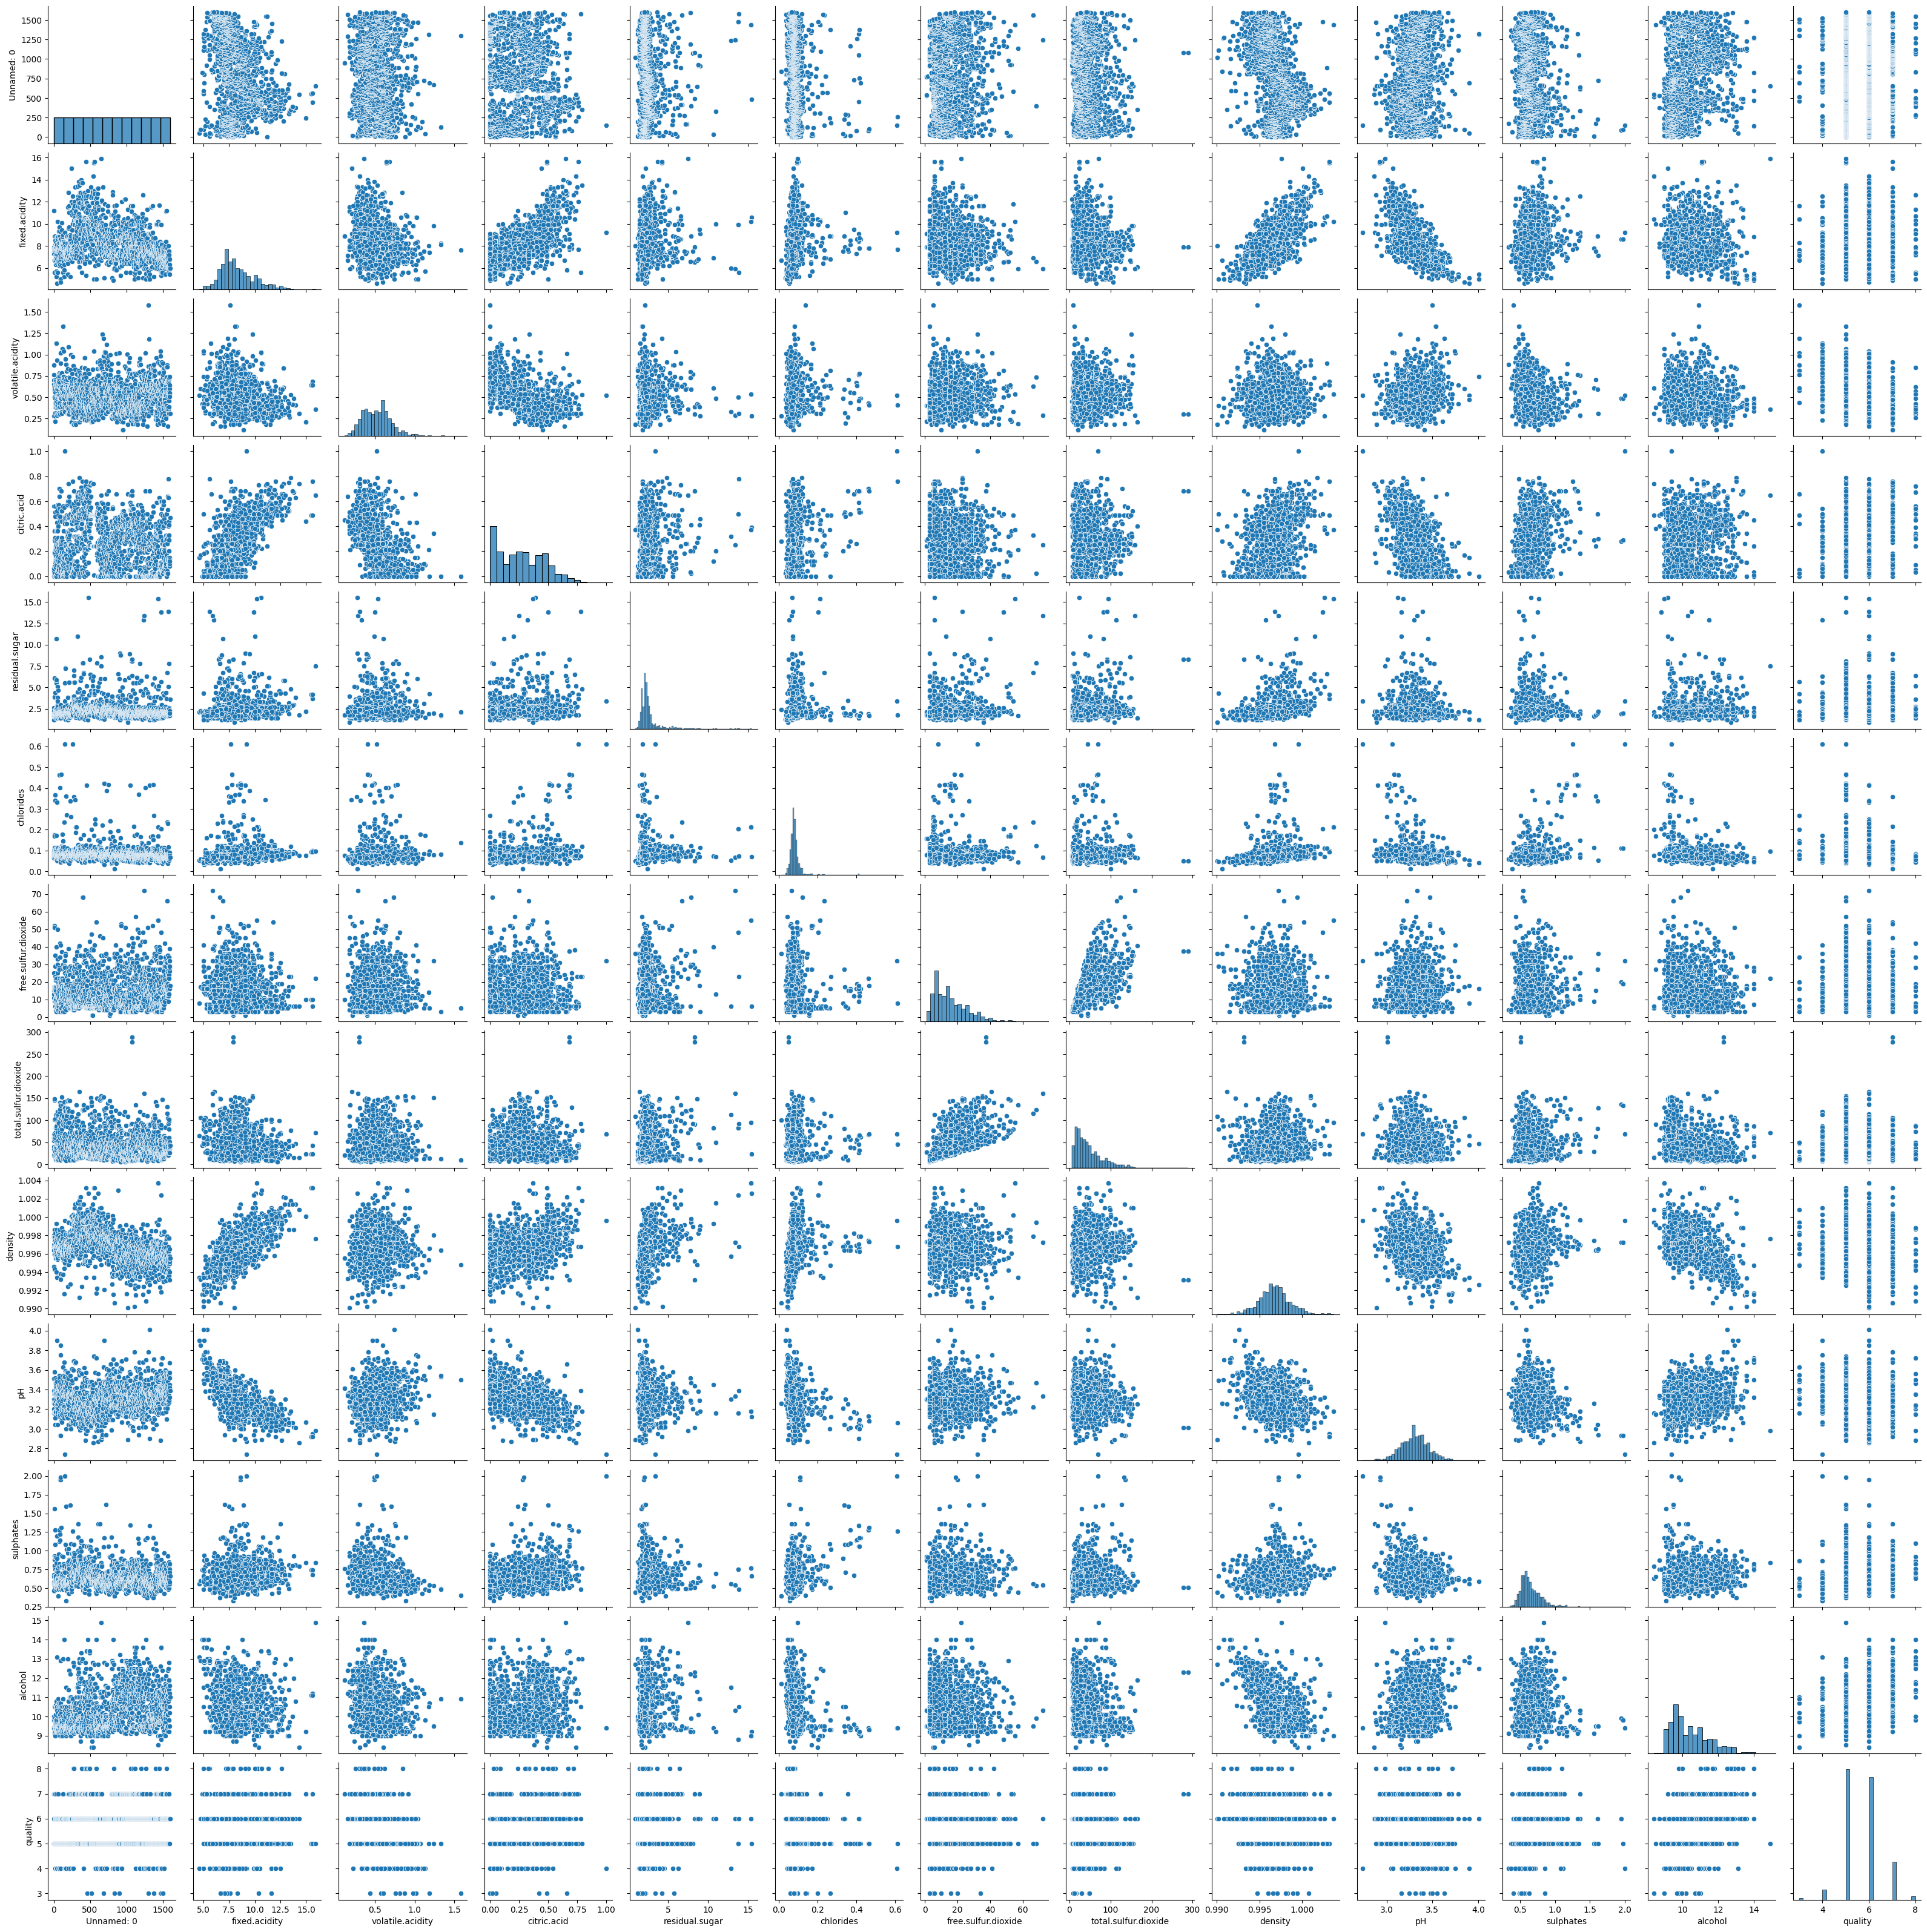

In [10]:
# Make a pairplot of the wine data to show pairwise relationships between the variables.
# This allows us to visually examine distributions and relationships.
sns.pairplot(wine)

# Display the pairplot.
plt.show()

If you've never executed your own Seaborn pairplot before, just take a moment to look at the output. They certainly output a lot of information at once. What can you infer from it? What can you *not* justifiably infer from it?

Answer: The pairplot shows the relationships and distributions between the different wine variables. I can use it to identify possible correlations, patterns, and relationships between variables. For example, some variables appear to have stronger relationships than others.

However, I cannot conclude that one variable causes another just because they appear related in the pairplot. I also cannot determine statistical significance or make strong conclusions about the relationships without doing additional statistical analysis.

All done.
 

Here's a couple things you might have noticed: 
- a given cell value represents the correlation that exists between two variables 
- on the diagonal, you can see a bunch of histograms. This is because pairplotting the variables with themselves would be pointless, so the pairplot() method instead makes histograms to show the distributions of those variables' values. This allows us to quickly see the shape of each variable's values.  
- the plots for the quality variable form horizontal bands, due to the fact that it's a discrete variable. We were certainly right in not pursuing a regression analysis of this variable.
- Notice that some of the nice plots invite a line of best fit, such as alcohol vs density. Others, such as citric acid vs alcohol, are more inscrutable.

So we now have called the .corr() method, and the .pairplot() Seaborn method, on our wine data. Both have flaws. Happily, we can get the best of both worlds with a heatmap. 

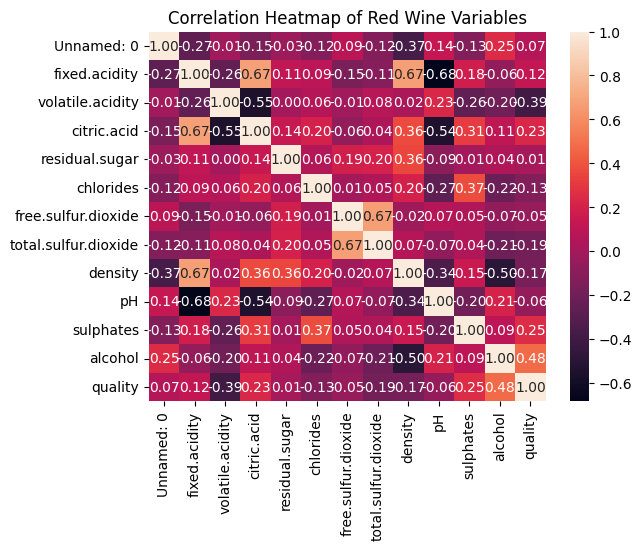

In [11]:
# Make a heatmap of the data 
# Calculate the correlation matrix and store it in a variable.
corr = wine.corr(numeric_only=True)

# Create a heatmap of the correlation matrix.
# annot=True displays the correlation values inside each cell.
# fmt=".2f" formats the values to two decimal places.
sns.heatmap(corr, annot=True, fmt=".2f")

# Add a title to the heatmap.
plt.title("Correlation Heatmap of Red Wine Variables")

# Display the plot.
plt.show()


Take a moment to think about the following questions:
- How does color relate to extent of correlation?
- How might we use the plot to show us interesting relationships worth investigating? 
- More precisely, what does the heatmap show us about the fixed acidity variable's relationship to the density variable? 

Answer: The heatmap allows us to quickly identify stronger positive and negative relationships. For this case study, density has a relatively strong positive correlation with fixed.acidity, making it an interesting predictor.

There is a relatively strong correlation between the density and fixed acidity variables respectively. In the next code block, call the scatterplot() method on our sns object. Make the x-axis parameter 'density', the y-axis parameter 'fixed.acidity', and the third parameter specify our wine dataset.  

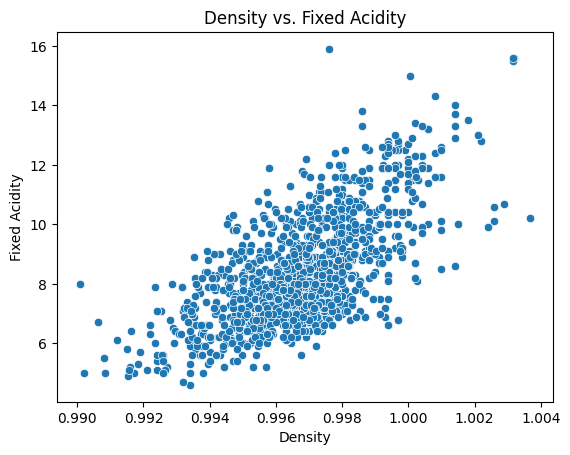

In [12]:
# Plot density against fixed.acidity
# Create a scatterplot showing the relationship between density and fixed acidity.
sns.scatterplot(x="density", y="fixed.acidity", data=wine)

# Label the x-axis.
plt.xlabel("Density")

# Label the y-axis.
plt.ylabel("Fixed Acidity")

# Add a title.
plt.title("Density vs. Fixed Acidity")

# Display the plot.
plt.show()

We can see a positive correlation, and quite a steep one. There are some outliers, but as a whole, there is a steep looking line that looks like it ought to be drawn. 

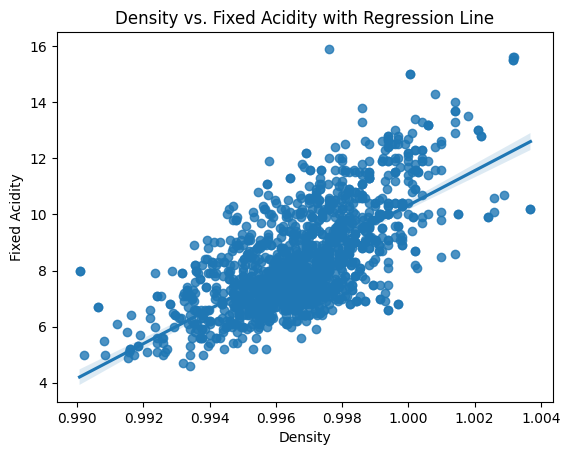

In [13]:
# Create a scatterplot with a linear regression line. 
# Call the regplot method on your sns object, with parameters: x = 'density', y = 'fixed.acidity'
sns.regplot(x="density", y="fixed.acidity", data=wine)

# Label the x-axis.
plt.xlabel("Density")

# Label the y-axis.
plt.ylabel("Fixed Acidity")

# Add a title.
plt.title("Density vs. Fixed Acidity with Regression Line")

# Display the plot.
plt.show()

The line of best fit matches the overall shape of the data, but it's clear that there are some points that deviate from the line, rather than all clustering close. 

Let's see if we can predict fixed acidity based on density using linear regression. 

### 3. Modeling 

#### 3a. Train/Test Split
While this dataset is super clean, and hence doesn't require much for analysis, we still need to split our dataset into a test set and a training set.

You'll recall from p.158 of *AoS* that such a split is important good practice when evaluating statistical models. On p.158, Professor Spiegelhalter was evaluating a classification tree, but the same applies when we're doing regression. Normally, we train with 75% of the data and test on the remaining 25%. 

To be sure, for our first model, we're only going to focus on two variables: fixed acidity as our dependent variable, and density as our sole independent predictor variable. 

We'll be using [sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) here. Don't worry if not all of the syntax makes sense; just follow the rationale for what we're doing. 

In [14]:
# Subsetting our data into our dependent and independent variables.
# Double brackets keep X as a DataFrame rather than converting it to a Series.
X = wine[["density"]]

# Select fixed acidity as the dependent/target variable.
y = wine["fixed.acidity"]

# Split the data. This line uses the sklearn function train_test_split().
# The test_size parameter means we can train with 75% of the data, and test on 25%. 
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

In [15]:
# We now want to check the shape of the X train, y_train, X_test and y_test to make sure the proportions are right. 
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1199, 1)
y_train shape: (1199,)
X_test shape: (400, 1)
y_test shape: (400,)


#### 3b. Making a Linear Regression model: our first model
Sklearn has a [LinearRegression()](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) function built into the linear_model module. We'll be using that to make our regression model. 

In [16]:
# Create the model: make a variable called rModel, and use it linear_model.LinearRegression appropriately
rModel = linear_model.LinearRegression()

In [17]:
# We now want to train the model on our test data.
rModel.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[609.89]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['density']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-599.6
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [18]:
# Evaluate the model  
rModel.score(X_test, y_test)

0.49042335553888394

The above score is called R-Squared coefficient, or the "coefficient of determination". It's basically a measure of how successfully our model predicts the variations in the data away from the mean: 1 would mean a perfect model that explains 100% of the variation. At the moment, our model explains only about 45% of the variation from the mean. There's more work to do!

In [19]:
# Use the model to make predictions about our test data
y_pred = rModel.predict(X_test)

# Display the first few predictions.
y_pred[:10]

array([ 8.52151768,  7.85063338, 10.53417056,  9.07042301,  7.11875961,
        8.46052819,  8.07019551,  7.60667546,  7.97261235,  7.13705645])

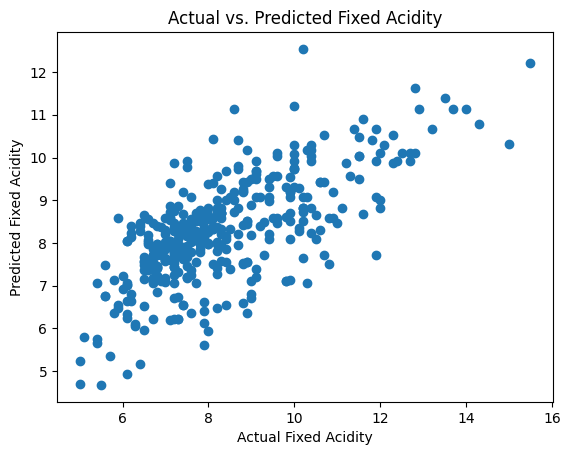

In [20]:
# Let's plot the predictions against the actual result. Use scatter()
plt.scatter(y_test, y_pred)

# Label the x-axis as the actual values.
plt.xlabel("Actual Fixed Acidity")

# Label the y-axis as the predicted values.
plt.ylabel("Predicted Fixed Acidity")

# Add a title.
plt.title("Actual vs. Predicted Fixed Acidity")

# Display the plot.
plt.show()

The above scatterplot represents how well the predictions match the actual results. 

Along the x-axis, we have the actual fixed acidity, and along the y-axis we have the predicted value for the fixed acidity.

There is a visible positive correlation, as the model has not been totally unsuccesful, but it's clear that it is not maximally accurate: wines with an actual fixed acidity of just over 10 have been predicted as having acidity levels from about 6.3 to 13.

Let's build a similar model using a different package, to see if we get a better result that way.

#### 3c. Making a Linear Regression model: our second model: Ordinary Least Squares (OLS)

In [21]:
# Create the test and train sets. Here, we do things slightly differently.  
# We make the explanatory variable X as before.
X = wine[["density"]]

# But here, reassign X the value of adding a constant to it. This is required for Ordinary Least Squares Regression.
# Further explanation of this can be found here: 
# https://www.statsmodels.org/devel/generated/statsmodels.regression.linear_model.OLS.html
X = sm.add_constant(X)


In [22]:
# The rest of the preparation is as before.
y = wine["fixed.acidity"]

# Split the data using train_test_split()
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=123
)

In [23]:
# Create the model
# The dependent variable is y_train and the predictors are X_train.
rModel2 = sm.OLS(y_train, X_train)

# Fit the model with fit() 
rModel2 = rModel2.fit()

In [24]:
# Evaluate the model with .summary()
# Display the complete OLS regression summary.
# This includes R-squared, coefficients, standard errors,
# t-statistics, p-values, confidence intervals, and other diagnostics.
rModel2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          fixed.acidity   R-squared:                       0.455
Model:                            OLS   Adj. R-squared:                  0.454
Method:                 Least Squares   F-statistic:                     998.8
Date:                Thu, 24 Sep 2026   Prob (F-statistic):          6.68e-160
Time:                        22:18:08   Log-Likelihood:                -2011.0
No. Observations:                1199   AIC:                             4026.
Df Residuals:                    1197   BIC:                             4036.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -615.7316     19.746    -31.182      0.000    -654.473    -576.990
density      626.0927     19.810     31.604      0.000     587.226     664.959
==============================================================================
Omnibus:                       94.056   Durbin-Watson:                   1.985
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              122.229
Skew:                           0.668   Prob(JB):                     2.87e-27
Kurtosis:                       3.812   Cond. No.                     1.06e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.06e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

One of the great things about Statsmodels (sm) is that you get so much information from the summary() method. 

There are lots of values here, whose meanings you can explore at your leisure, but here's one of the most important: the R-squared score is 0.455, the same as what it was with the previous model. This makes perfect sense, right? It's the same value as the score from sklearn, because they've both used the same algorithm on the same data.

Here's a useful link you can check out if you have the time: https://www.theanalysisfactor.com/assessing-the-fit-of-regression-models/

In [25]:
# Let's use our new model to make predictions of the dependent variable y. Use predict(), and plug in X_test as the parameter
y_pred2 = rModel2.predict(X_test)

# Display the first few predictions.
y_pred2[:10]

912     8.319997
772     8.996177
1037    8.307475
1106    6.454241
263     8.044516
1029    7.656339
935     7.499816
1280    7.606251
31      8.232344
512     9.108874
dtype: float64

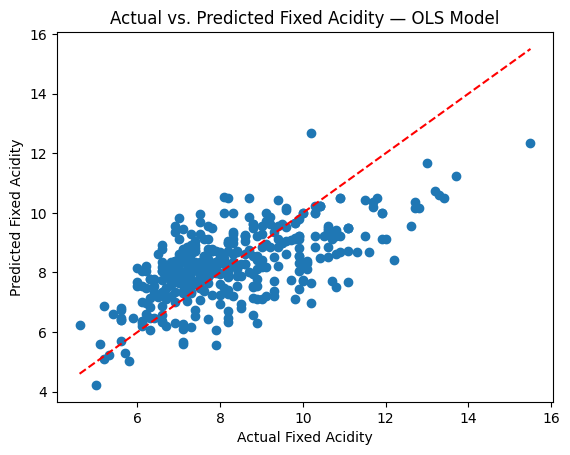

In [26]:
# Create a scatterplot comparing actual and predicted fixed acidity.
plt.scatter(y_test, y_pred2)

# Add a line for perfect correlation. 
# Add a line representing perfect predictions.
# If the predictions were perfect, every point would fall on y = x.
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

# Label the x-axis.
plt.xlabel("Actual Fixed Acidity")

# Label the y-axis.
plt.ylabel("Predicted Fixed Acidity")

# Add a title.
plt.title("Actual vs. Predicted Fixed Acidity — OLS Model")

# Display the plot.
plt.show()

The red line shows a theoretically perfect correlation between our actual and predicted values - the line that would exist if every prediction was completely correct. It's clear that while our points have a generally similar direction, they don't match the red line at all; we still have more work to do. 

To get a better predictive model, we should use more than one variable.

#### 3d. Making a Linear Regression model: our third model: multiple linear regression
Remember, as Professor Spiegelhalter explains on p.132 of *AoS*, including more than one explanatory variable into a linear regression analysis is known as ***multiple linear regression***. 

In [27]:
# Create test and train datasets
# This is again very similar, but now we include more columns in the predictors
# Include all columns from data in the explanatory variables X except fixed.acidity and quality (which was an integer)
X = wine.drop(columns=["fixed.acidity", "quality"])

# Define fixed acidity as the dependent/target variable.
y = wine["fixed.acidity"]

# Add a constant/intercept column to the explanatory variables.
# This is required for the statsmodels OLS model.
X = sm.add_constant(X)

# Split the predictors and dependent variable into training and testing sets.
# 75% is used for training and 25% is used for testing.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [28]:
# Create the third OLS regression model using multiple predictors.
rModel3 = sm.OLS(y_train, X_train)

# Fit the multiple linear regression model to the training data.
rModel3 = rModel3.fit()

In [29]:
# Evaluate the model
rModel3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          fixed.acidity   R-squared:                       0.865
Model:                            OLS   Adj. R-squared:                  0.863
Method:                 Least Squares   F-statistic:                     688.9
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:18:08   Log-Likelihood:                -1148.5
No. Observations:                1199   AIC:                             2321.
Df Residuals:                    1187   BIC:                             2382.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 -611.1018     15.706    -38.909      0.000    -641.916    -580.287
Unnamed: 0              -0.0002    4.4e-05     -4.577      0.000      -0.000      -0.000
volatile.acidity         0.3429      0.136      2.516      0.012       0.076       0.610
citric.acid              1.9730      0.157     12.584      0.000       1.665       2.281
residual.sugar          -0.2586      0.015    -16.974      0.000      -0.288      -0.229
chlorides               -3.6098      0.444     -8.125      0.000      -4.481      -2.738
free.sulfur.dioxide      0.0124      0.003      4.908      0.000       0.007       0.017
total.sulfur.dioxide    -0.0074      0.001     -9.087      0.000      -0.009      -0.006
density                634.3570     15.655     40.520      0.000     603.642     665.072
pH                      -5.3171      0.150    -35.359      0.000      -5.612      -5.022
sulphates               -0.7817      0.124     -6.305      0.000      -1.025      -0.538
alcohol                  0.5571      0.025     22.294      0.000       0.508       0.606
==============================================================================
Omnibus:                      106.586   Durbin-Watson:                   2.023
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              341.183
Skew:                           0.417   Prob(JB):                     8.18e-75
Kurtosis:                       5.477   Cond. No.                     1.12e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.12e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

The R-Squared score shows a big improvement - our first model predicted only around 45% of the variation, but now we are predicting 87%!

In [30]:
# Use our new model to make predictions
y_pred3 = rModel3.predict(X_test)

# Display the first few predictions.
y_pred3[:10]

803      7.983207
124      6.886199
350     10.285906
682      9.054022
1326     6.985964
976      7.485680
1493     7.335077
706      7.002982
613      8.463809
1587     6.075286
dtype: float64

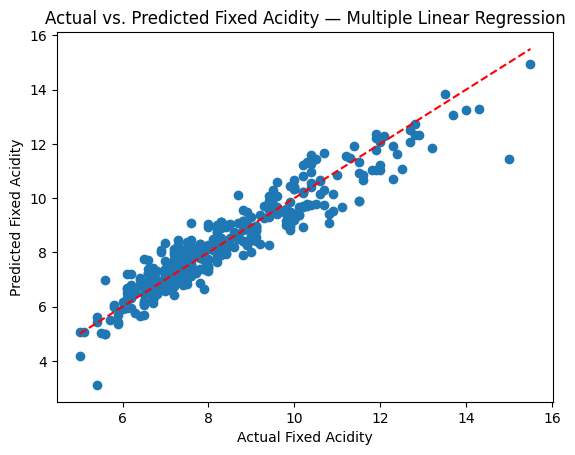

In [31]:
# Create a scatterplot comparing actual and predicted fixed acidity.
plt.scatter(y_test, y_pred3)

# Add a line showing perfect predictions.
# Points on this line have predicted values equal to actual values.
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
#    linewidth=2
    "r--"
)

# Label the x-axis.
plt.xlabel("Actual Fixed Acidity")

# Label the y-axis.
plt.ylabel("Predicted Fixed Acidity")

# Add a title.
plt.title("Actual vs. Predicted Fixed Acidity — Multiple Linear Regression")

# Display the plot.
plt.show()

We've now got a much closer match between our data and our predictions, and we can see that the shape of the data points is much more similar to the red line. 

We can check another metric as well - the RMSE (Root Mean Squared Error). The MSE is defined by Professor Spiegelhalter on p.393 of *AoS*, and the RMSE is just the square root of that value. This is a measure of the accuracy of a regression model. Very simply put, it's formed by finding the average difference between predictions and actual values. Check out p. 163 of *AoS* for a reminder of how this works. 

In [32]:
# Define a function to calculate Root Mean Squared Error (RMSE).
def rmse(y_actual, y_predicted):
    
    # Calculate Mean Squared Error first.
    mse = mean_squared_error(y_actual, y_predicted)
    
    # Take the square root of MSE to obtain RMSE.
    return np.sqrt(mse)

In [33]:
# Get predictions from rModel3 or the multiple linear regression model.
y_pred3 = rModel3.predict(X_test)

# Put the predictions & actual values into a dataframe
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred3
})

# Display the first few rows.
results.head()

# Calculate the RMSE between the actual and predicted fixed acidity values.
model3_rmse = rmse(y_test, y_pred3)

# Display the RMSE.
model3_rmse


np.float64(0.5889923639944603)

The RMSE tells us how far, on average, our predictions were mistaken. An RMSE of 0 would mean we were making perfect predictions. 0.6 signifies that we are, on average, about 0.6 of a unit of fixed acidity away from the correct answer. That's not bad at all.

#### 3e. Making a Linear Regression model: our fourth model: avoiding redundancy 

We can also see from our early heat map that volatile.acidity and citric.acid are both correlated with pH. We can make a model that ignores those two variables and just uses pH, in an attempt to remove redundancy from our model.

In [34]:
# Select six predictors for the fourth model.
# These variables are used to predict fixed acidity while leaving out
# variables that may contain redundant information.
X = wine[
    [
        "pH",
        "residual.sugar",
        "chlorides",
        "free.sulfur.dioxide",
        "total.sulfur.dioxide",
        "alcohol"
    ]
]

# Select fixed acidity as the dependent variable.
y = wine["fixed.acidity"]

# Create constants for X, so the model knows its bounds
X = sm.add_constant(X)

# Split the data into training and testing sets.
# 75% is used for training and 25% for testing.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


In [35]:
# Create the fourth OLS regression model.
rModel4 = sm.OLS(y_train, X_train)

# Fit the fourth model using the training data.
rModel4 = rModel4.fit()

# Display the regression summary.
# This allows us to compare the model's R-squared and other statistics
# with the previous models.
rModel4.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          fixed.acidity   R-squared:                       0.494
Model:                            OLS   Adj. R-squared:                  0.492
Method:                 Least Squares   F-statistic:                     194.0
Date:                Thu, 24 Sep 2026   Prob (F-statistic):          1.81e-172
Time:                        22:18:08   Log-Likelihood:                -1938.6
No. Observations:                1199   AIC:                             3891.
Df Residuals:                    1192   BIC:                             3927.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   34.0793      0.870     39.167      0.000      32.372      35.786
pH                      -7.8619      0.244    -32.177      0.000      -8.341      -7.382
residual.sugar           0.1070      0.026      4.178      0.000       0.057       0.157
chlorides               -3.2283      0.754     -4.280      0.000      -4.708      -1.749
free.sulfur.dioxide     -0.0032      0.005     -0.680      0.497      -0.012       0.006
total.sulfur.dioxide    -0.0077      0.001     -5.147      0.000      -0.011      -0.005
alcohol                  0.0665      0.036      1.861      0.063      -0.004       0.137
==============================================================================
Omnibus:                       83.548   Durbin-Watson:                   2.070
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              103.802
Skew:                           0.635   Prob(JB):                     2.88e-23
Kurtosis:                       3.680   Cond. No.                     1.67e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.67e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

The R-squared score has reduced, showing us that actually, the removed columns were important.

### Conclusions & next steps

Congratulations on getting through this implementation of regression and good data science practice in Python! 

Take a moment to reflect on which model was the best, before reading on.

.
.
.

Here's one conclusion that seems right. While our most predictively powerful model was rModel3, this model had explanatory variables that were correlated with one another, which made some redundancy. Our most elegant and economical model was rModel4 - it used just a few predictors to get a good result. 

All of our models in this notebook have used the OLS algorithm - Ordinary Least Squares. There are many other regression algorithms, and if you have time, it would be good to investigate them. You can find some examples [here](https://www.statsmodels.org/dev/examples/index.html#regression). Be sure to make a note of what you find, and chat through it with your mentor at your next call.
